# 使用K-最近邻算法构建鸢尾花分类模型

## 1、加载并查看数据集

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 导入sklearn自带的数据集库，导入iris数据集

from sklearn.datasets import load_iris

# 鸢尾花数据集是sklearn自带数据集，使用load_iris函数加载
iris = load_iris()

print(iris.keys()) # 查看数据集的组成部分


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
data = iris.data # 150朵鸢尾花的特征数据
print(data.shape)# 共150行，4列
print(iris.feature_names) # 每一列分别是花萼长度、花萼宽度，花瓣长度，花瓣宽度


(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
# 每一行数据所属的种类，即数据的标签，(0-Setosa,1-Versicolor,2-Virginica)
target = iris.target
print(target)

target_names = iris.target_names # 三种鸢尾花的名称
print(target_names)

feature_names = iris.feature_names # 四个特征的名称
print(feature_names)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
import pandas as pd

# 创建DataFrame，完整显示数据集内容
df = pd.DataFrame(data, columns=feature_names) # 创建DataFrame，添加列索引
df['target'] = target # 增加类别列
df['target_name'] = df['target'].map(lambda i: target_names[i])
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


## 2、数据集可视化

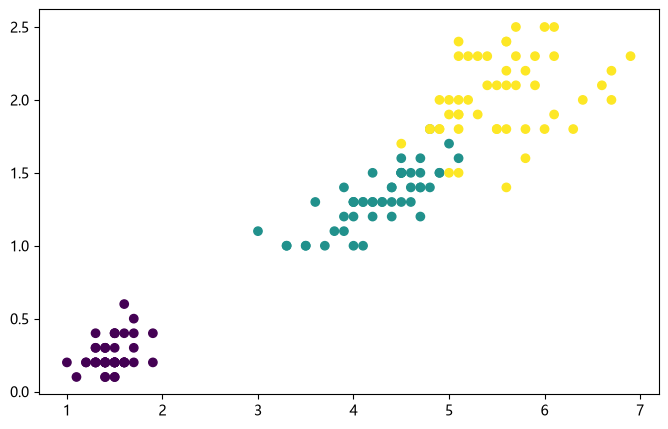

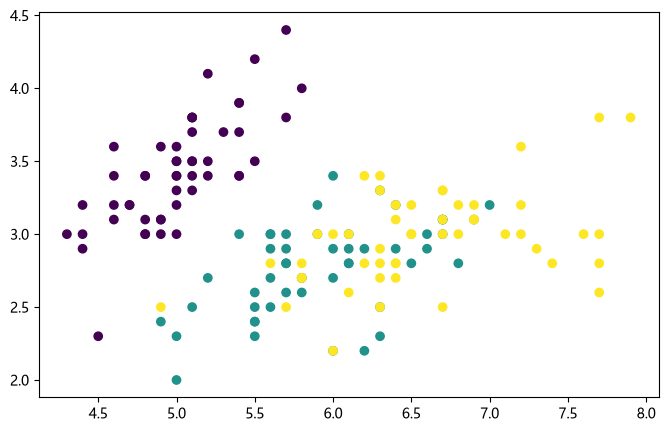

In [6]:
import matplotlib.pyplot as plt

# 鸢尾花画瓣数据集散点图可视化
fig = plt.figure(figsize=(8,5))# 定义画板尺寸 8,5
plt.scatter(data[:, 2], data[:, 3], c=target)  # 花瓣长度 vs 花瓣宽度

# 鸢尾花萼片数据集散点图可视化
fig2 = plt.figure(figsize=(8,5))
plt.scatter(data[:, 0], data[:, 1], c=target)  # 花萼长度 vs 花萼宽度
plt.show()


### 2.1、更详细的可视化方法

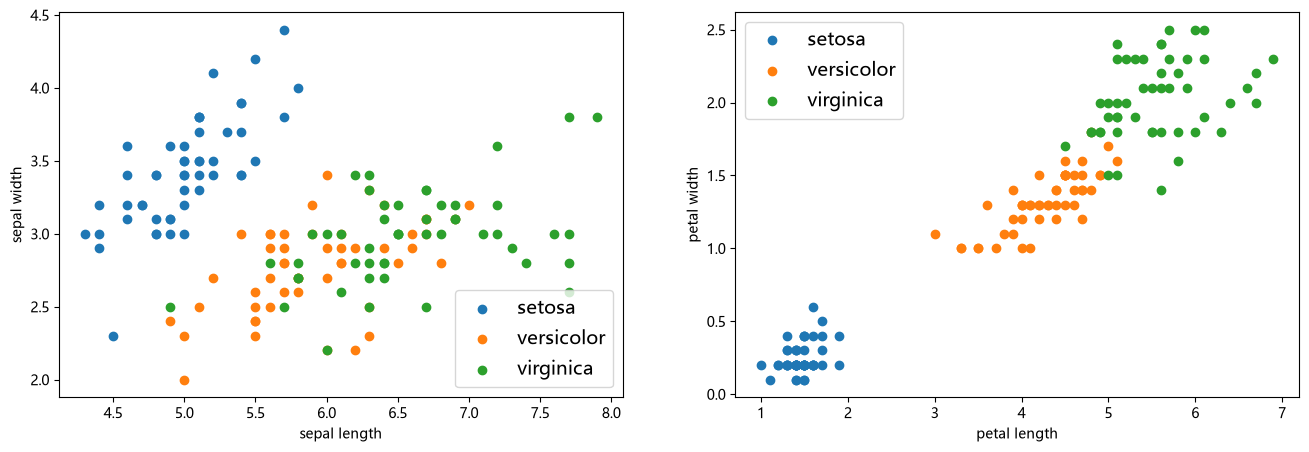

In [7]:
# 鸢尾花数据集可视化
fig = plt.figure(figsize=(16,5)) # 定义画板尺寸

# 添加第一个子图，可视化花萼长宽数据
# 分类画出花萼数据的散点图
ax1 = fig.add_subplot(1, 2, 1)
for i, name in enumerate(target_names):
    ax1.scatter(data[target==i, 0], data[target==i, 1], label=name)

ax1.set_xlabel('sepal length') # x轴标签
ax1.set_ylabel('sepal width') # y轴标签
ax1.legend(fontsize=14)

# 添加第二个子图，可视化花瓣长宽数据
# 分类画出花瓣数据的散点图
ax2 = fig.add_subplot(1, 2, 2)
for i, name in enumerate(target_names):
    ax2.scatter(data[target==i, 2], data[target==i, 3], label=name)
ax2.set_xlabel('petal length')
ax2.set_ylabel('petal width')
ax2.legend(fontsize=14)
plt.show()


## 3、拆分数据集

In [8]:
from sklearn.model_selection import train_test_split

# 使用train_test_split函数将数据集拆分为训练集和测试集
# 特征数据和标签都需要进行拆分（参数1、2）
# test_size 指定测试集的比例（默认0.25，即25%的数据作为测试集，其余作为训练集）
# random_state 指定随机数种子，确保每次运行结果相同
# 通常用大写X_来表示数据，小写y_来表示标签
# 返回值依次是训练集数据、测试集数据、训练集标签、测试集标签
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.25, random_state=0)
print(X_train.shape) # 训练集尺寸
print(X_test.shape)  # 测试集尺寸


(112, 4)
(38, 4)


## 4、创建K-最近邻分类模型，并评估模型

In [9]:
# 导入模块
from sklearn.neighbors import KNeighborsClassifier

# 创建KNN分类器，参数n_neighbors=3表示用最近的3个邻居来判断1个数据点的类型
model = KNeighborsClassifier(n_neighbors=3)

# 拟合数据，即：将训练数据和标签交给模型去学习
model.fit(X_train, y_train)

# 使用score方法在测试集上评估模型成绩
score = model.score(X_test, y_test)
print('score:', score)


score: 0.9736842105263158


## 5、使用模型进行预测

In [10]:
import numpy as np
# 1、预测测试集中前10条数据的种类
y_pred = model.predict(X_test[:10])
print('y_pred:', y_pred)
print('y_true:', y_test[:10]) # 打印实际标签与预测结果作对比

# 2、假设我们新测量了一朵鸢尾花的四个特征值，用模型预测它的种类
X_new = np.array([[5, 2.9, 1, 0.2]])
prediction = model.predict(X_new) # 使用predict方法进行预测
print('prediction :', prediction) # 输出预测结果（标签）
print('prediction names:', target_names[prediction[0]]) # 输出预测的种类名称


y_pred: [2 1 0 2 0 2 0 1 1 1]
y_true: [2 1 0 2 0 2 0 1 1 1]
prediction : [0]
prediction names: setosa
